In [12]:
# --- 1. SETUP & LIBRARIES ---
library(dplyr)
library(tidyr)
library(ggplot2)
library(gridExtra)

In [13]:
data_dir <- '/home/mjehangir/telomere-sv-analysis/data/'
setwd(data_dir)

In [14]:
# --- 2. DATA LOADING & PRE-PROCESSING ---
df_cnv <- read.delim("Mean_normalized_v3_tab.seg", header = TRUE)
df_arms <- read.delim("chm13_p_q_arm_length.tsv", header = TRUE)

In [15]:
# Standardize chromosome naming
df_cnv <- df_cnv %>% 
  mutate(chrom = paste0("chr", chrom)) %>%
  filter(num.mark > 0)

In [16]:
# Classify Gains and Losses
df_cnv <- df_cnv %>%
  mutate(Gain_Loss = case_when(
    seg.mean < -0.2 ~ "Loss",
    seg.mean > 0.2 ~ "Gain",
    TRUE ~ "Neutral"
  )) %>%
  filter(Gain_Loss != "Neutral")

In [17]:
# --- 3. ARM & CHROMOSOME METRICS ---
# Map segments to arms
df_cnv_with_arms <- df_cnv %>%
  left_join(df_arms, by = c("chrom" = "Chromosome")) %>%
  filter(loc.start >= Start & loc.end <= End) %>%
  mutate(size_mb = (loc.end - loc.start) / 1e6)

Warning message in left_join(., df_arms, by = c(chrom = "Chromosome")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 3 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [18]:
# --- 4. VISUALIZATION 1: CNV Burden Sorted by Sample ---
# Calculate counts per sample
cnv_counts_per_sample <- df_cnv %>%
  group_by(ID, Gain_Loss) %>%
  summarise(count = n(), .groups = "drop")

In [19]:


# Display head of final processed data
head(df_cnv_with_arms)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss,Start,End,Length,Arm,size_mb
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<int>,<int>,<int>,<chr>,<dbl>
1,2436A,chr1,142707663,142907814,2,1.3533,Gain,124048267,248387328,124339061,q,0.200151
2,2436A,chr10,113132775,120741705,39,-0.4022,Loss,40649191,134758134,94108943,q,7.608930
3,2436A,chr10,123144525,124546170,8,-0.2972,Loss,40649191,134758134,94108943,q,1.401645
4,2436A,chr10,124746405,134357666,48,-0.4613,Loss,40649191,134758134,94108943,q,9.611261
5,2436A,chr15,18027720,19630184,6,0.3728,Gain,17186630,99753195,82566565,q,1.602464
6,2436A,chr18,39469935,39670290,2,-0.4876,Loss,18449624,80542538,62092914,q,0.200355


In [20]:
# Ensure data is filtered and colors are set
df_cnv_plot <- df_cnv %>%
  filter(Gain_Loss != "Neutral") %>%
  mutate(Gain_Loss = factor(Gain_Loss, levels = c("Loss", "Gain")))

cnv_colors <- c("Loss" = "blue", "Gain" = "#E41A1C")

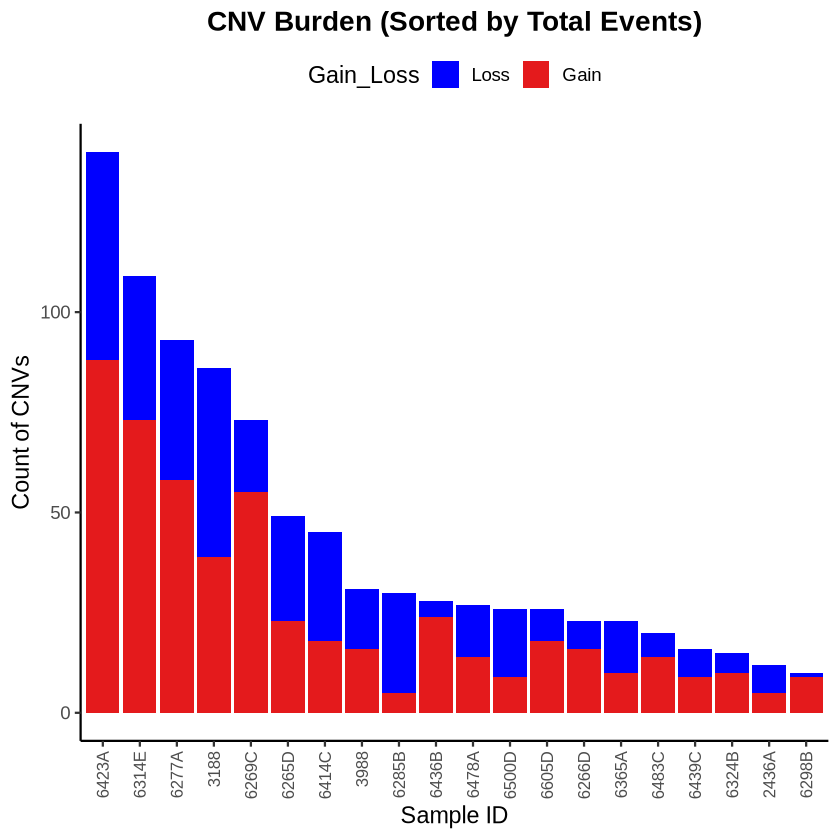

In [26]:
# --- 2. PLOT A1: SORTED BY TOTAL BURDEN ---
plot_burden_sorted <- ggplot(df_cnv_plot, 
                             aes(x = reorder(ID, ID, function(x) -length(x)), fill = Gain_Loss)) +
  geom_bar(stat = "count", position = "stack") +
  theme_classic(base_size = 14) +
  scale_fill_manual(values = cnv_colors) +
  labs(
    title = "CNV Burden (Sorted by Total Events)",
    x = "Sample ID",
    y = "Count of CNVs"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 10),
    legend.position = "top",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )
                                             print(plot_burden_sorted)
#ggsave("CNV_Burden_Sorted.pdf", plot = plot_burden_sorted, width = 7, height = 5)
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/CNVs/CNV_Burden_sorted.pdf", plot = plot_burden_sorted, width = 7, height = 5)

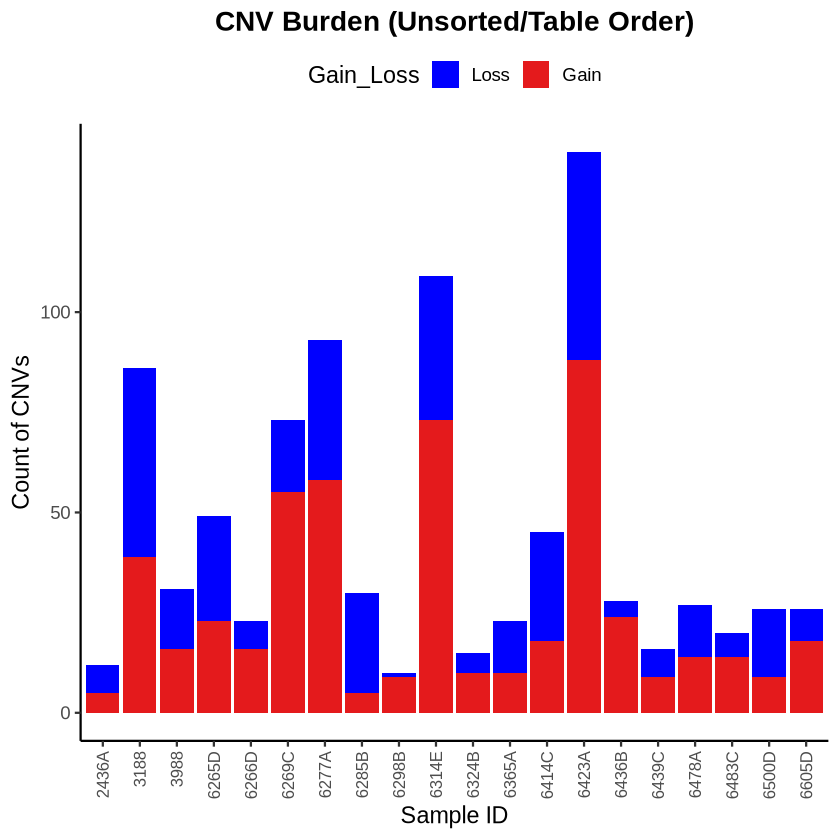

In [25]:
# UNSORTED (MATCHES TABLE ORDER) ---
plot_burden_unsorted <- ggplot(df_cnv_plot, aes(x = ID, fill = Gain_Loss)) +
  geom_bar(stat = "count", position = "stack") +
  theme_classic(base_size = 14) +
  scale_fill_manual(values = cnv_colors) +
  labs(
    title = "CNV Burden (Unsorted/Table Order)",
    x = "Sample ID",
    y = "Count of CNVs"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 10),
    legend.position = "top",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

# --- 4. DISPLAY ---
print(plot_burden_unsorted)

# --- 5. EXPORT ---
#ggsave("CNV_Burden_Sorted.pdf", plot = plot_burden_sorted, width = 7, height = 5)
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/CNVs/CNV_Burden_Unsorted.pdf", plot = plot_burden_unsorted, width = 7, height = 5)

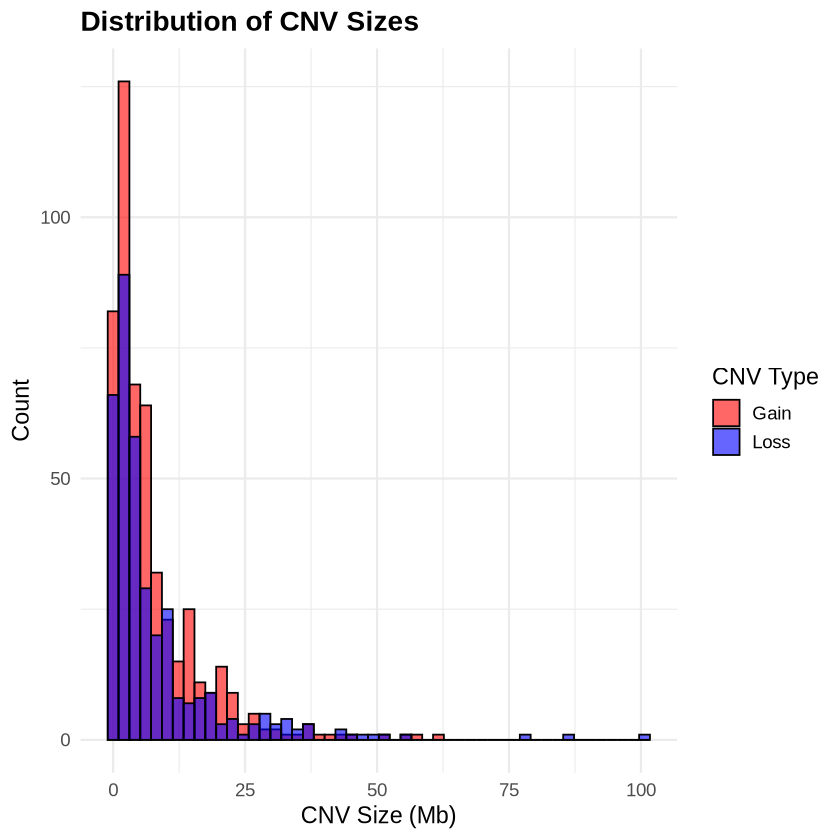

In [23]:
# --- 5. VISUALIZATION 2: Size Distribution (Histogram) ---
plot_histogram <- ggplot(df_cnv_with_arms, aes(x = size_mb, fill = Gain_Loss)) +
  geom_histogram(position = "identity", bins = 50, alpha = 0.6, color = "black") +
  scale_fill_manual(values = c("Gain" = "red", "Loss" = "blue")) +
  theme_minimal(base_size = 14) +
  labs(title = "Distribution of CNV Sizes", 
       x = "CNV Size (Mb)", y = "Count", fill = "CNV Type") +
  theme(plot.title = element_text(face = "bold"))
plot_histogram

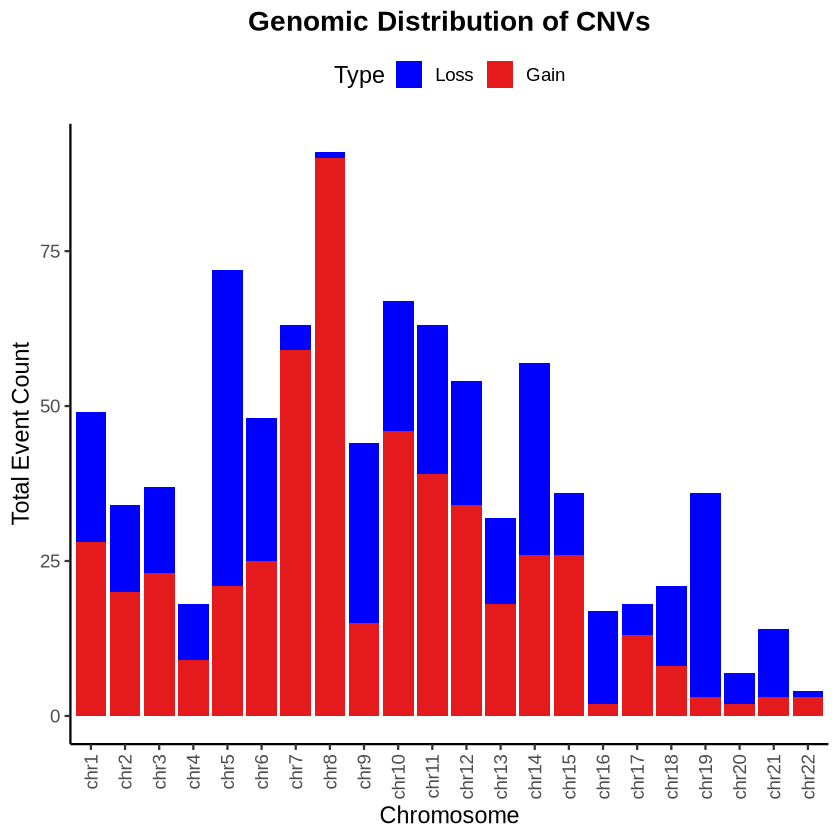

In [24]:

# Ensure Gain_Loss is a factor for consistent coloring
df_cnv_plot <- df_cnv %>%
  filter(Gain_Loss != "Neutral") %>%
  mutate(Gain_Loss = factor(Gain_Loss, levels = c("Loss", "Gain")))

# Define standard publication colors
cnv_colors <- c("Loss" = "blue", "Gain" = "#E41A1C")


# --- 3. PLOT B: CNV COUNTS PER CHROMOSOME (STACKED) ---
# Ensure chromosomes are in natural order (1-22, X, Y)
chr_order <- paste0("chr", c(1:22, "X", "Y"))
df_cnv_plot$chrom <- factor(df_cnv_plot$chrom, levels = chr_order)

plot_chr_distribution <- ggplot(df_cnv_plot, aes(x = chrom, fill = Gain_Loss)) +
  geom_bar(stat = "count", position = "stack") +
  theme_classic(base_size = 14) +
  scale_fill_manual(values = cnv_colors) +
  labs(
    title = "Genomic Distribution of CNVs",
    x = "Chromosome",
    y = "Total Event Count",
    fill = "Type"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    legend.position = "top",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

print(plot_chr_distribution)



In [ ]:

# Save Burden Plot
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/CNVs/CNV_per_sample.pdf",
    #   plot = plot_burden, width = 6, height = 5)

# Save Histogram Plot
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data/plots_f1/CNV_size_histogram.pdf", 
     #  plot = plot_histogram, width = 8, height = 6)